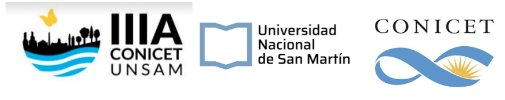  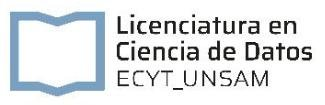

---

# NB06 — Aprendizaje no supervisado: clustering y segmentación

Lo que veremos en esta notebook:

- [x] Por qué empezamos con aprendizaje no supervisado antes del supervisado
- [x] K-means: algoritmo, limitaciones y elección de k
- [x] Gaussian Mixture Models: una generalización probabilística
- [x] Selección de modelo con BIC
- [x] Evaluación post-hoc con etiquetas (tabla de contingencia, ARI)
- [x] Segmentación con SLIC: superpíxeles como unidad de análisis
- [x] Puente hacia el supervisado de NB08
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Ejecutar K-means y GMM sobre una imagen satelital e interpretar las agrupaciones.
- Justificar la elección de k combinando criterios estadísticos (BIC) con interpretabilidad del resultado.
- Diagnosticar los aciertos y errores del clustering comparándolo post-hoc con etiquetas conocidas.
- Generar una segmentación SLIC y usarla como unidad de análisis en lugar del píxel.
- Leer un clustering *como hipótesis* sobre la estructura del territorio, no como verdad.

### Datos con los que trabajaremos

- `data/raw_data/satelital/S2_AMBANO_B02B03B04B08_2026feb.tif` — imagen Sentinel-2.
- `data/raw_data/vectorial/zona_dique.geojson` — recorte del área de interés.
- `data/proc/dataset_etiquetado.npz` — etiquetas de NB04, usadas *solo* para la evaluación post-hoc del clustering.

### Conexión con el arco del curso

**¿Por qué clustering antes de clasificación supervisada?** Tradicionalmente se enseña primero lo supervisado y después lo no supervisado. Invertimos ese orden porque es el orden natural del *análisis* cuando uno se enfrenta a un territorio nuevo: antes de decir qué clases queremos clasificar, conviene preguntarle a los datos **qué estructura tienen**. El resultado de esta clase va a informar, confirmar o cuestionar nuestro esquema de 6 clases de NB04.

El cierre de la clase prepara explícitamente NB08: vamos a comparar el mapa de clusters de esta notebook con el mapa supervisado que produciremos allá. Esa comparación es un diagnóstico metodológico central.

---
# 0. Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask as rasterio_mask
import geopandas as gpd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import slic, mark_boundaries

from ade_tools import componer_rgb, ecualizar_rgb, guardar_geotiff

RAW  = 'data/raw_data/'
PROC = 'data/proc/'

FN_IMG  = RAW + 'satelital/S2_AMBANO_B02B03B04B08_2026feb.tif'
FN_ZONA = RAW + 'vectorial/zona_dique.geojson'

# CLASES_ORD se deriva del dataset corregido al cargarlo — ver sección 1

---
# 1. Preparación de los datos

In [ ]:
# Recortamos al área del Dique
gdf_zona = gpd.read_file(FN_ZONA)
with rasterio.open(FN_IMG) as src:
    crs_img = src.crs
    if gdf_zona.crs != crs_img:
        gdf_zona = gdf_zona.to_crs(crs_img)
    geoms = [gdf_zona.geometry.iloc[0].__geo_interface__]
    imagen, T = rasterio_mask(src, geoms, crop=True)
    perfil = src.profile.copy()
    nodata = src.nodata

perfil.update({'height':imagen.shape[1],'width':imagen.shape[2],'transform':T})

# Calculamos NDVI y NDWI sobre el recorte
ESCALA = 10_000.0
azul, verde, rojo, nir = (imagen[i].astype(float)/ESCALA for i in range(4))
ndvi = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)
ndwi = np.where((verde + nir) != 0, (verde - nir) / (verde + nir), np.nan)

# Máscara de validez: píxeles con TODAS las bandas válidas
nodata_val = 0 if nodata is None else nodata
validos = np.all(imagen != nodata_val, axis=0) & ~np.isnan(ndvi) & ~np.isnan(ndwi)
print(f'Dimensiones imagen: {imagen.shape[1]}×{imagen.shape[2]}')
print(f'Píxeles válidos   : {validos.sum():,}  ({validos.mean()*100:.1f}%)')

In [ ]:
# Feature matrix: un vector de 6 features por cada píxel válido
features = np.stack([azul, verde, rojo, nir, ndvi, ndwi], axis=-1)
X_img = features[validos]   # (n_validos, 6)

# Cargamos el dataset etiquetado ahora (en vez de más adelante), para ajustar
# el scaler sobre la UNIÓN de los dos conjuntos. Esto evita un desajuste
# de escala entre los píxeles del recorte del Dique y los ROIs del territorio
# completo (los ROIs de NB04 pueden incluir polígonos fuera del recorte).
data_etiq  = np.load(PROC + 'dataset_etiquetado_corregido.npz', allow_pickle=True)
X_etiq_raw = data_etiq['X']
y_etiq     = data_etiq['y']
# Orden canónico derivado del dataset corregido (incluye las subclases de rural de NB05)
CLASES_ORD = tuple(sorted(np.unique(y_etiq)))
print(f'Clases en dataset corregido: {CLASES_ORD}')

# Estandarizamos con un scaler ajustado sobre ambos conjuntos
scaler = StandardScaler().fit(np.vstack([X_img, X_etiq_raw]))
X_std      = scaler.transform(X_img)
X_etiq_std = scaler.transform(X_etiq_raw)

print(f'X_std      shape: {X_std.shape}   (píxeles válidos del recorte del Dique)')
print(f'X_etiq_std shape: {X_etiq_std.shape}   (dataset etiquetado NB04)')

---
# 2. K-means

**K-means** (MacQueen, 1967) busca una partición de los datos en $k$ grupos que minimiza la suma de distancias cuadradas al centroide del grupo (inercia intra-cluster, WSS):

$$\mathcal{L}(c_1, ..., c_k) = \sum_{i=1}^n \| x_i - c_{z_i} \|^2$$

donde $z_i$ es el cluster asignado al dato $i$.

**Algoritmo (Lloyd):**
1. Inicializar $k$ centroides (habitualmente con k-means++).
2. Asignar cada dato al centroide más cercano.
3. Recalcular cada centroide como el promedio de sus datos.
4. Repetir 2-3 hasta convergencia.

**Asunciones implícitas** que vale la pena hacer explícitas:
- Los clusters son **esféricos** e **isotrópicos** en el espacio de features. Si una clase es alargada en una dirección, K-means la va a romper en pedazos.
- Los clusters tienen **tamaño parecido** — la distancia al centroide es el único criterio.
- Cada dato pertenece a **exactamente un** cluster (asignación dura).

Las tres asunciones se pueden relajar usando GMM (que vemos después).

In [ ]:
# Primera corrida con k=6 (el número de clases que tenemos en NB04)
km6 = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X_std)
labels_km6 = km6.labels_

# Reconstruimos el mapa: cada píxel válido tiene su cluster
mapa_km6 = np.full(imagen.shape[1:], -1, dtype=int)
mapa_km6[validos] = labels_km6

# Visualización
from matplotlib.colors import ListedColormap
colores_cluster = ['#1f77b4','#17becf','#2ca02c','#8c564b','#d62728','#ff7f0e']
cmap_cluster = ListedColormap(colores_cluster[:6])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(componer_rgb(imagen, [2,1,0]))
axes[0].set_title('Imagen original — color natural')
axes[0].axis('off')

mapa_mask = np.where(mapa_km6 == -1, np.nan, mapa_km6)
axes[1].imshow(mapa_mask, cmap=cmap_cluster, vmin=0, vmax=5)
axes[1].set_title('K-means con k=6')
axes[1].axis('off')

plt.suptitle('Clustering K-means sobre el Dique Roggero', fontsize=13)
plt.tight_layout()
plt.show()

---
# 3. ¿Cuántos clusters?

Dos criterios clásicos para elegir $k$ en K-means:

### 3.1 Método del codo

Graficamos la inercia (WSS) en función de $k$. La inercia siempre decrece con más clusters. Buscamos un "codo" — un $k$ a partir del cual agregar clusters da poco rédito. Es visualmente intuitivo pero subjetivo, y el codo a veces no es claro.

### 3.2 Silhouette

Para cada punto se calcula el silhouette coefficient:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

donde $a(i)$ es la distancia media a los otros puntos de su cluster y $b(i)$ es la distancia media a los puntos del cluster vecino más cercano. $s(i) \in [-1, 1]$, valores cerca de 1 indican buena asignación.

El silhouette promedio tiende a preferir $k$ más chicos. Ambos criterios son útiles pero ambos son aproximaciones — el criterio definitivo es siempre la **interpretabilidad**.

In [ ]:
# Barrido de k=2 a 11
from sklearn.metrics import silhouette_score

# Submuestreamos para calcular silhouette (escala cuadrática con n, prohibitivo con todos los píxeles)
n_sample = min(5000, X_std.shape[0])
idx_sample = np.random.RandomState(0).choice(X_std.shape[0], n_sample, replace=False)
X_sample = X_std[idx_sample]

ks = list(range(2, 12))
inercias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_std)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_sample, km.predict(X_sample))
    silhouettes.append(sil)
    print(f'k={k:2d}  inercia={km.inertia_:,.0f}  silhouette={sil:.3f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, inercias, 'o-', markersize=8)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WSS)')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

axes[1].plot(ks, silhouettes, 'o-', color='darkred', markersize=8)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette promedio')
axes[1].set_title('Silhouette score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# 4. Gaussian Mixture Models

Un **GMM** modela los datos como mezcla ponderada de $k$ gaussianas:

$$p(x) = \sum_{j=1}^{k} \pi_j\, \mathcal{N}(x\,|\, \mu_j, \Sigma_j), \quad \sum_j \pi_j = 1$$

Los parámetros $\pi_j, \mu_j, \Sigma_j$ se estiman por EM (*Expectation-Maximization*). Comparado con K-means:

| Aspecto | K-means | GMM |
|---|---|---|
| Forma de los clusters | esféricos | elípticos (cada uno con su $\Sigma$) |
| Tamaño de clusters | similar | flexible con $\pi_j$ |
| Asignación | dura | probabilística (*soft*) |
| Asunción gaussiana | no explícita | explícita |

El GMM es una generalización estricta de K-means —de hecho, K-means equivale a un GMM con $\Sigma_j = \sigma^2 I$ fijo y asignación al máximo-a-posteriori. En geografía, las clases raramente son esféricas en el espacio espectral: GMM suele ajustar mejor.

In [ ]:
# Ajustamos GMM con k=6
gmm = GaussianMixture(n_components=6, covariance_type='full',
                      random_state=42, max_iter=200).fit(X_std)
labels_gmm = gmm.predict(X_std)

mapa_gmm = np.full(imagen.shape[1:], -1, dtype=int)
mapa_gmm[validos] = labels_gmm

# Visualizamos los dos mapas lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(componer_rgb(imagen, [2,1,0]))
axes[0].set_title('Imagen original')
axes[0].axis('off')

mapa_km_m = np.where(mapa_km6 == -1, np.nan, mapa_km6)
axes[1].imshow(mapa_km_m, cmap=cmap_cluster, vmin=0, vmax=5)
axes[1].set_title('K-means, k=6')
axes[1].axis('off')

mapa_gmm_m = np.where(mapa_gmm == -1, np.nan, mapa_gmm)
axes[2].imshow(mapa_gmm_m, cmap=cmap_cluster, vmin=0, vmax=5)
axes[2].set_title('GMM, k=6')
axes[2].axis('off')

plt.suptitle('K-means vs GMM con el mismo k', fontsize=13)
plt.tight_layout()
plt.show()

## 4.1 Selección de modelo con BIC

El criterio BIC (Schwarz, 1978) balancea la verosimilitud del modelo contra su complejidad:

$$\text{BIC} = -2 \ln \hat{L} + p \ln n$$

donde $\hat{L}$ es la máxima verosimilitud del modelo, $p$ es el número de parámetros libres, y $n$ el tamaño de la muestra. **Se prefiere el modelo con BIC más bajo**. Agregar componentes al GMM aumenta $\hat{L}$ pero también $p$; BIC penaliza la segunda parte y encuentra un equilibrio.

Fraley & Raftery (2002) argumentan extensamente por BIC como criterio estándar para selección de componentes en GMM, aunque no es el único (AIC también se usa).

In [ ]:
# Barrido BIC
# ADVERTENCIA DE CÓMPUTO: calcular el BIC de un GMM full-covariance sobre
# todos los píxeles (~300k) es costoso (~varios minutos por k). Lo calculamos
# sobre una muestra representativa de 10000 píxeles, suficiente para estimar
# el k óptimo con precisión comparable al barrido completo.
n_bic = min(20_000, X_std.shape[0])
idx_bic = np.random.RandomState(42).choice(X_std.shape[0], n_bic, replace=False)
X_bic = X_std[idx_bic]

print(f'Barrido BIC sobre {n_bic:,} píxeles de muestra (de {X_std.shape[0]:,} totales)')
bics = []
for k in ks:
    gmm_k = GaussianMixture(n_components=k, covariance_type='full',
                             random_state=42, max_iter=100).fit(X_bic)
    bics.append(gmm_k.bic(X_bic))
    print(f'  k={k:2d}  BIC={bics[-1]:,.0f}')

k_optimo_bic = ks[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, bics, 'o-', color='darkred', markersize=8)
ax.axvline(k_optimo_bic, color='gray', linestyle='--', alpha=0.5, label=f'min en k={k_optimo_bic}')
ax.set_xlabel('k'); ax.set_ylabel('BIC')
ax.set_title('Selección de k por BIC (GMM, muestra 20k píxeles)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'BIC mínimo en k = {k_optimo_bic}')

El BIC puede sugerir más o menos clusters que nuestras 6 clases de NB04. Típicamente las clases de información (nuestras etiquetas) están compuestas de múltiples clases espectrales.  Esto es información interesante: **el dato tiene su propia estructura**, que puede coincidir con la humana o no. Esquemáticamente, hay dos lecturas posibles:

1. **BIC < 6.** Algunas clases que distinguimos a mano no son espectralmente distintas con estas 4 bandas. Habría que agregar features o aceptar el colapso.
2. **BIC > 6.** Nuestras clases son más gruesas que la información espectral. Por ejemplo, "urbano" podría partirse en "techo de tejas", "techo de chapa", "asfalto". Es la típica situación en teledetección en la que las clases de información están compuestas de múltiples clases espectrales. A veces este número es tan alto que no es conveniente utilizar el _n_ óptimo.

Para dirimirlo **comparamos los dos GMMs**: el entrenado con $k=6$ (nuestra hipótesis humana) y el entrenado con $k=k^\star_{\text{BIC}}$ (la estructura que el dato prefiere).

In [ ]:
# Ajustamos un segundo GMM con el k óptimo del BIC y lo comparamos
gmm_bic = GaussianMixture(n_components=k_optimo_bic, covariance_type='full',
                           random_state=42, max_iter=200).fit(X_std)
labels_bic = gmm_bic.predict(X_std)

mapa_bic = np.full(imagen.shape[1:], -1, dtype=int)
mapa_bic[validos] = labels_bic

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(np.where(mapa_gmm == -1, np.nan, mapa_gmm), cmap='tab10', vmin=0, vmax=9)
axes[0].set_title(f'GMM con k=6 (nuestro esquema humano)'); axes[0].axis('off')
axes[1].imshow(np.where(mapa_bic == -1, np.nan, mapa_bic), cmap='tab10', vmin=0, vmax=9)
axes[1].set_title(f'GMM con k={k_optimo_bic} (óptimo BIC)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Nota: los colores de los clusters NO son comparables entre las dos figuras.')
print(f'Mirá las regiones, no los colores: ¿qué se subdivide / se funde al cambiar k?')

---
# 5. Evaluación post-hoc: ¿coincide el clustering con lo que etiquetamos?

El clustering es no supervisado, pero tenemos etiquetas de los ROIs de NB05. Podemos hacer una **evaluación post-hoc**: para los píxeles que SÍ están etiquetados, ¿a qué cluster los asignó el algoritmo? Si cada clase humana cae mayoritariamente en un único cluster (o viceversa), el clustering reconstruyó la estructura que habíamos identificado.

> **Nota terminológica.** Usamos deliberadamente *evaluación* y no *validación*. Un modelo estadístico puede compararse con datos, medirse, contrastarse — pero la noción de que puede ser "validado" (declarado correcto o verdadero) es epistemológicamente problemática: ninguna cantidad de evidencia confirmatoria prueba un modelo, solo puede refutarlo (Popper, 1959). Lo que medimos acá es la **concordancia** entre dos maneras distintas de organizar los mismos datos — la partición no supervisada y la partición humana — no la verdad de ninguna de las dos. Recomiendo ver Oreskes, et al. (1994). "*Verification, validation, and confirmation of numerical models in the earth sciences*", Science.

Dos herramientas:
- **Tabla de contingencia** normalizada por fila: `% de cada clase que cae en cada cluster`. Si el acuerdo es alto, las filas son cercanas a *one-hot*.
- **Adjusted Rand Index (ARI)**: un escalar entre -1 y 1 que mide la concordancia entre dos particiones. 1 = idénticas, 0 = como al azar, negativo = peor que al azar.

In [ ]:
# Evaluación post-hoc: ya cargamos X_etiq_std al inicio (sección 1).
# Clasificamos los píxeles etiquetados con el GMM entrenado.
clusters_etiq = gmm.predict(X_etiq_std)

# Tabla de contingencia normalizada por fila
ct = pd.crosstab(pd.Series(y_etiq, name='clase'),
                 pd.Series(clusters_etiq, name='cluster'),
                 normalize='index') * 100

# Ordenamos las filas según CLASES_ORD
ct = ct.reindex(index=[c for c in CLASES_ORD if c in ct.index])

print('% de cada clase asignada a cada cluster del GMM:')
print(ct.round(1))

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
import seaborn as sns
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu', vmax=100, ax=ax,
            cbar_kws={'label':'% de la clase en el cluster'})
ax.set_title('Clases (filas) versus clusters (columnas) — porcentaje por fila')
ax.set_xlabel('Cluster GMM'); ax.set_ylabel('Clase verdadera')
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(y_etiq, clusters_etiq)
print(f'\nAdjusted Rand Index: {ari:.3f}')

**Lectura:** si la clase `agua` aparece casi al 100% en un único cluster, el algoritmo separó bien agua. Si `urbano` se reparte entre dos clusters y `suelo_desnudo` se mezcla con ellos, **estamos viendo concretamente el resultado que anticipamos con la matriz JM de NB05**: los pares con baja separabilidad aparecen mezclados en el clustering.

Esa correspondencia es un diagnóstico doble: confirma los análisis de NB05 y nos dice que el clustering reproduce fielmente la geometría del espacio de features.

---
# 6. Segmentación con SLIC

Hasta acá cada píxel fue una unidad de análisis independiente. Esto tiene un costo: los mapas resultantes tienen un aspecto **ruidoso** porque dos píxeles vecinos pueden caer en clusters distintos solo por pequeñas variaciones de reflectancia.

**SLIC** (*Simple Linear Iterative Clustering*, Achanta et al. 2012) produce **superpíxeles**: regiones contiguas de píxeles espectralmente similares. Funciona como un K-means restringido a vecindarios en el espacio 5D `(Lab_L, Lab_a, Lab_b, x, y)`, con un parámetro de compacidad que balancea similaridad espectral versus cohesión espacial.

Los superpíxeles tienen dos ventajas:

- **Unidad de análisis más estable**: estadísticas por superpíxel suavizan el ruido por píxel.
- **Costo computacional menor**: con 10000 superpíxeles cubrimos lo que con $10^6$ píxeles — toda la cadena posterior corre 100x más rápido.

In [ ]:
# SLIC sobre la composición RGB de índices (R=NDVI, G=NDWI, B=NIR)
rgb_indices = np.stack([ndvi, ndwi, nir], axis=-1).astype(np.float32)
# Reemplazamos NaN por un valor neutro para SLIC
rgb_indices_nan = np.nan_to_num(rgb_indices, nan=0.0)

# Objetivo: ~8000 superpíxeles sobre los píxeles válidos
n_obj = 8000
n_seg = int(n_obj * (rgb_indices.shape[0]*rgb_indices.shape[1]) / max(validos.sum(), 1))

# Compatibilidad entre versiones de skimage:
#  * channel_axis es el argumento correcto desde 0.19; antes era multichannel=True
#  * el parámetro mask existe desde 0.17
def _slic_compat(img, n_segments, compactness, mask):
    try:
        return slic(img, n_segments=n_segments, compactness=compactness,
                    channel_axis=-1, start_label=0, mask=mask)
    except TypeError:
        pass
    try:
        return slic(img, n_segments=n_segments, compactness=compactness,
                    multichannel=True, start_label=0, mask=mask)
    except TypeError:
        # Versión muy vieja sin soporte de mask: corremos sin mask y marcamos
        # los píxeles fuera del recorte con -1 después.
        seg = slic(img, n_segments=n_segments, compactness=compactness,
                   multichannel=True, start_label=0)
        seg[~mask] = -1
        return seg

segmentos = _slic_compat(rgb_indices_nan, n_seg, 10, validos)

n_sp_real = len(np.unique(segmentos[segmentos >= 0]))
print(f'Segmentos pedidos : {n_seg}')
print(f'Segmentos obtenidos: {n_sp_real}')

In [ ]:
# Visualización: la imagen con los bordes de los superpíxeles
rgb = componer_rgb(imagen, [2,1,0])
bordes = mark_boundaries(rgb, segmentos, color=(1,1,0), mode='inner')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(rgb)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(bordes)
axes[1].set_title(f'Segmentación SLIC — {n_sp_real} superpíxeles')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Los superpíxeles respetan fronteras reales del paisaje — ríos, bordes urbanos, parcelas — mejor que una grilla regular de cuadrados. Eso los hace una unidad de análisis que captura discontinuidades naturales del territorio.

En el **Ejercicio 2** vas a usar los superpíxeles como entidades para el clustering: calcular un feature promedio por superpíxel y correr K-means sobre los superpíxeles. El resultado visual es dramáticamente más limpio que el clustering píxel a píxel.

---
# 7. Guardado de productos

In [ ]:
# Guardamos el mapa de clusters GMM y la segmentación SLIC
guardar_geotiff(PROC + 'mapa_cluster_gmm_dique_2026feb.tif',
                mapa_gmm.astype(np.int16), perfil, nodata=-1,
                nombres_bandas=['cluster_gmm'])

guardar_geotiff(PROC + 'segmentacion_slic_dique_2026feb.tif',
                segmentos.astype(np.int32), perfil, nodata=-1,
                nombres_bandas=['segmento_slic'])

El mapa GMM va a tener un rol explícito en **NB08**: vamos a entrenar un Random Forest supervisado sobre los ROIs y después comparar el mapa supervisado con este mapa GMM píxel por píxel. Dos mapas construidos con lógicas distintas que coinciden son una fuerte evidencia de que ambas reflejan estructura real. Donde difieran, hay algo para investigar — típicamente donde los ROIs son pocos o donde la separabilidad es baja.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Barrido de k

a) Corré K-means con $k \in \{3, 5, 8, 12\}$ sobre el dataset espectral y generá los cuatro mapas resultantes sobre la zona del Dique. Mostralos en una grilla 2×2.

b) Para cada uno, interpretá qué cubierta identifica cada cluster. ¿Con qué $k$ emerge una distinción clara entre agua, humedal, cultivo y urbano? ¿Qué aparece cuando $k=12$ que no aparecía con $k=6$?

c) Argumentá con los resultados cuál es, a tu criterio, el $k$ más útil para esta imagen y este territorio. Tu respuesta debe combinar evidencia numérica (codo, silhouette) con interpretabilidad.

*Esqueleto:*
```python
ks = [3, 5, 8, 12]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, k in zip(axes.ravel(), ks):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_std)
    mapa = np.full(imagen.shape[1:], -1, dtype=int)
    mapa[validos] = km.labels_
    mapa_m = np.where(mapa == -1, np.nan, mapa)
    ax.imshow(mapa_m, cmap='tab20'); ax.set_title(f'k={k}'); ax.axis('off')
plt.tight_layout(); plt.show()
```

---

## Ejercicio 2 — Clustering sobre superpíxeles

a) Para cada superpíxel generado por SLIC, calculá el vector medio de las 6 features (bandas + índices). Deberías obtener una matriz `(n_superpixels, 6)`.

b) Corré K-means con $k=6$ y después GMM con $k$ = el óptimo por BIC, sobre esa matriz. Cada algoritmo te devuelve la etiqueta de cluster de cada superpíxel.

c) Pintá el mapa: cada superpíxel pintado del color de su cluster. Compará con el clustering píxel a píxel — ¿qué gana en interpretabilidad? ¿Qué pierde en resolución espacial?

---

## Ejercicio 3 — ARI versus comparación visual

a) Calculá el Adjusted Rand Index entre el GMM y las etiquetas de los ROIs, y entre K-means y las etiquetas.

b) ¿Es esperable que GMM dé un ARI más alto que K-means? ¿Por qué?

c) Un ARI bajo no implica un clustering "malo" — puede reflejar que el algoritmo encontró una partición igualmente válida pero diferente de la nuestra. Da un ejemplo concreto de una partición distinta a la de NB04 que podría ser defendible.

---

## Ejercicio opcional — Hard vs soft assignments

GMM asigna probabilidades, no clases duras. Usá `gmm.predict_proba(X_std)` para obtener una matriz `(n_pixels, k)` con probabilidades.

a) Graficá la **entropía** de la distribución posterior sobre cada píxel: zonas con entropía alta son aquellas donde el modelo tiene dudas.

b) Superpon el mapa de entropía con la imagen original. ¿Dónde ocurren las zonas de duda? Suelen ser:
   - Píxeles mixtos en bordes (entre dos coberturas contiguas).
   - Píxeles de una cobertura cuya firma espectral es intermedia entre dos clusters.

c) Discutí por qué los soft-assignments son más honestos para un mapa de cobertura que los hard-assignments, aunque sean más difíciles de visualizar.

*Punteros:* Reynolds (2009) *Gaussian Mixture Models* (enciclopedia de biometría); Achanta et al. (2012) *IEEE TPAMI* para SLIC; Bishop (2006) cap. 9 para GMM/EM.

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

No agregamos funciones nuevas a `ade_tools.py` en NB06: `sklearn` y `skimage` ya proveen implementaciones bien probadas. Armar wrappers triviales alrededor agregaría ruido sin valor.

La biblioteca del curso acumula:

- `escalar, componer_rgb, ecualizar_rgb, guardar_geotiff` (NB01, NB02)
- `estadisticas_zonales, extraer_pixeles_por_roi` (NB04)
- `jeffries_matusita` (NB05)